In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import html

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from joblib import dump

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Both Datasets

anime = pd.read_csv("anime.csv")
rating = pd.read_csv("rating.csv")

In [3]:
anime = anime.reset_index(drop=True)

In [4]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [6]:
# Check Dimension

print(anime.shape)
print(rating.shape)

(12294, 7)
(7813737, 3)


In [7]:
# EDA

# Dataset Information

anime.info()
rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [8]:
# Missing Values for anime

anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [9]:
# HAndling Missing Values for anime

anime['genre'] = anime['genre'].fillna('Unknown')

anime['type'] = anime['type'].fillna(anime['type'].mode()[0])

anime['rating'] = anime['rating'].fillna(anime['rating'].median())


In [10]:
# Verifying

anime.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [11]:
# missing value for rating

rating.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [12]:
# Clean Anime names

anime["name"] = anime["name"].map(lambda x: html.unescape(str(x)))
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama',"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


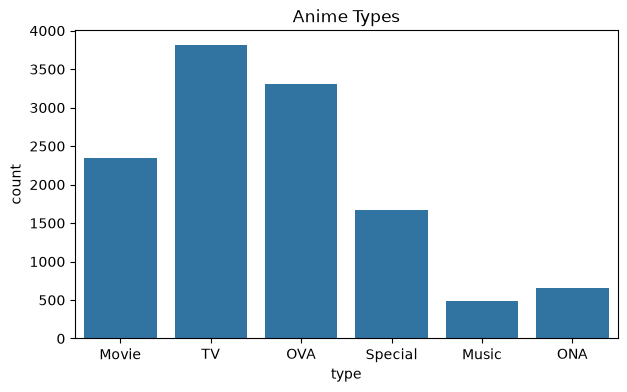

In [13]:
# Visualization

# Top Anime Types

plt.figure(figsize=(7,4))

sns.countplot(x='type', data = anime)

plt.title('Anime Types')

plt.show()

Interpretation:

The distribution of anime types is uneven across the dataset, with TV and OVA containing the highest number of records, while Music and ONA appear less frequently. This indicates that serialized anime content is more strongly represented in the collection. Since this project uses a content-based recommendation approach, no class balancing technique was applied because recommendations are generated based on similarity between anime attributes rather than predicting target classes.

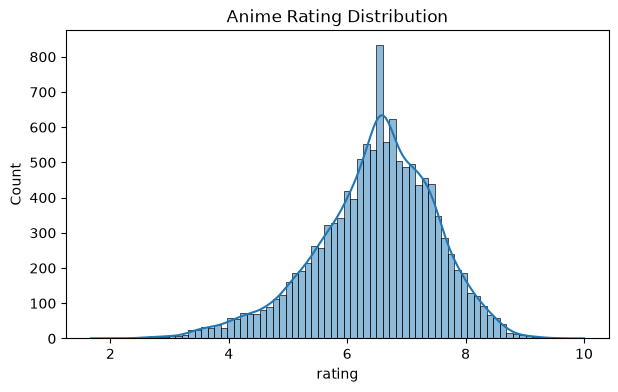

In [14]:
# Distribution of Rating

plt.figure(figsize=(7,4))

sns.histplot(anime['rating'], kde = True)

plt.title("Anime Rating Distribution")

plt.show()

Interpretaion:

The histogram above illustrates the distribution of anime ratings on a scale of 1 to 10, overlaid with a Kernel Density Estimate (KDE) curve to highlight the overall shape of the distribution. The distribution appears to be approximately bell-shaped but with a slight left skew, meaning that while most ratings are concentrated on the higher end of the scale, there is a longer tail extending toward the lower ratings. The majority of anime titles receive ratings between 6 and 8, with the peak or mode of the distribution occurring at approximately 6.5, indicating that this is the most frequently assigned rating across the dataset.

A particularly notable feature of this distribution is the sharp, narrow spike observed at around 6.5, which rises significantly above the KDE curve. This anomaly suggests that a disproportionately large number of anime titles received this specific rating, which could be attributed to a system default rating, a rounding convention, or a tendency among users to assign an "average" score when they are uncertain about a title. This spike is worth investigating further as it may introduce bias into any recommendation or clustering model built on top of this data.

At the extremes, very few anime titles receive ratings below 4 or above 9, which reflects a common pattern in user rating behavior where extremely poor or exceptionally outstanding titles are rare. The relative scarcity of low ratings may also suggest a selection bias, where users are more likely to rate anime they enjoyed rather than ones they abandoned early. Overall, the distribution reveals a moderate positive perception of anime across the dataset, with ratings leaning toward the above-average range, which is an important consideration when building models such as collaborative filtering or content-based recommendation systems.





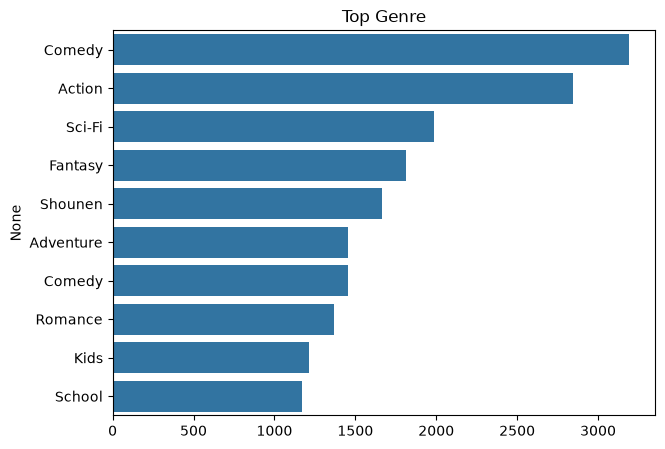

In [15]:
# Top Geners

genre_series = anime['genre'].str.split(',')

genre_flat = []

for i in genre_series:
    genre_flat.extend(i)

genre_df = pd.Series(genre_flat)

top = genre_df.value_counts().head(10)

plt.figure(figsize=(7,5))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Top Genre")

plt.show()


Interpretation:

The genre distribution shows that Comedy and Action are the most dominant genres in the anime dataset, followed by Sci-Fi and Fantasy. This indicates that the dataset contains a larger proportion of entertainment-focused, action-oriented, and imaginative content compared to niche genres. Genres such as Romance, Kids, and School are present but with comparatively lower representation. The unequal distribution suggests that recommendations generated through content similarity may more frequently return titles from highly represented genres because they contain more available examples for comparison. Since this project uses a content-based recommendation approach, genre information plays an important role in identifying similar anime and generating personalized recommendations.

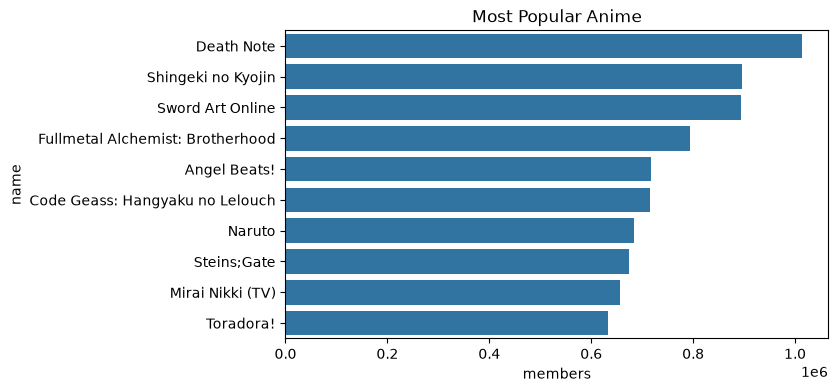

In [16]:
# Most Popular Anime

top_anime = anime.sort_values(by = 'members', ascending = False).head(10)

plt.figure(figsize = (7,4))
sns.barplot(x = 'members',
            y = 'name',
            data = top_anime)

plt.title("Most Popular Anime")
plt.show()


Interpretation:

The horizontal bar chart presents the top ten most popular anime titles based on the number of members who added them to their lists. Death Note appears as the most popular title in the dataset, followed by Shingeki no Kyojin and Sword Art Online, indicating strong audience engagement and broad recognition. Fullmetal Alchemist: Brotherhood, Angel Beats!, Code Geass, Naruto, and Steins;Gate also show high membership counts, reflecting sustained popularity across different anime audiences.

The results suggest that highly popular anime are primarily concentrated within action, fantasy, thriller, and adventure-oriented genres. Since popularity reflects user engagement and exposure, these titles may act as strong reference points in understanding viewing patterns. For this content-based recommendation system, popularity itself is not used as the recommendation mechanism; instead, anime attributes such as genre and type are used to identify and recommend similar titles. However, the popularity analysis provides useful insight into which categories are most strongly represented in the dataset.

In [17]:
# Distribution and Skewness

numeric_features = anime.select_dtypes(include=["number"])

numeric_features.skew()

anime_id    0.441550
rating     -0.553879
members     6.682934
dtype: float64

The members variable (6.68) exhibits extremely high positive skewness, indicating that a small number of anime have exceptionally large audience sizes while most titles have lower membership counts. To reduce skewness and improve distribution balance, a logarithmic transformation (log1p) was applied to the members feature.

In [18]:
# Log transformation on members

anime['members_log'] = np.log1p(anime['members'])

In [19]:
anime['members_log'].skew()

np.float64(0.2660955721578259)

In [20]:
# Build Content Based Recommender

# Create Features

anime['features'] = (anime['genre'].astype(str)+ ' '+anime['type'].astype(str))

In [21]:
# TF-IDF Vectorization : Convert text into numbers

tfidf = TfidfVectorizer(stop_words="english")
matrix = tfidf.fit_transform(anime['features'])

In [22]:
# Cosine Similarity

similarity = cosine_similarity(matrix)

In [23]:
# Create Index

indices = pd.Series(
    anime.index,
    index=anime['name']
).to_dict()

In [24]:
# Recommendation Function

def recommend(anime_name):

    #check if anime exists

    if anime_name not in indices:
        return "Anime not found"

    idx=indices[anime_name]

    if idx >= similarity.shape[0]:
        return "Index mismatch error"

    score = list(enumerate(similarity[idx]))

    score = sorted(score, key=lambda x:x[1], reverse = True)

    score = score[1:11]

    ids = [i[0] for i in score]

    return anime.iloc[ids][["name", "genre", "rating"]]

In [25]:
# Test Recommendation

recommend("Kimi no Na wa.")

,name,genre,rating
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",7.67
1494,Harmonie,"Drama, School, Supernatural",7.52
1959,Air Movie,"Drama, Romance, Supernatural",7.39
6394,Wind: A Breath of Heart (TV),"Drama, Romance, School, Supernatural",6.14
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",6.35
208,Kokoro ga Sakebitagatterunda.,"Drama, Romance, School",8.32
11082,Suki ni Naru Sono Shunkan wo.: Kokuhaku Jikkou...,"Comedy, Drama, Romance, School",6.57
2103,Clannad Movie,"Drama, Fantasy, Romance, School",7.35
878,Shakugan no Shana II (Second),"Action, Drama, Fantasy, Romance, School, Super...",7.79
986,Shakugan no Shana,"Action, Drama, Fantasy, Romance, School, Super...",7.74


In [26]:
# Save Recommendation Model

dump(similarity, "similarity.pkl")
dump(anime, "anime.pkl")
dump(tfidf, "tfidf.pkl")

['tfidf.pkl']